<a href="https://colab.research.google.com/github/zyf-hitsz/PytorchLearning/blob/main/%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/%E5%8D%B7%E7%A7%AF%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/DenseNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#稠密连接网络DenseNet
稠密连接网络在某种程度上是残差网络的逻辑拓展。

会议泰勒展开，通过多项式逼近的方法吧函数展开。同样的ResNet将函数展开为
$$f(x)=x+g(x)$$
残差网络将函数展开为一个简单的线性项和一个复杂的非线性项之和，在此基础上很多方案将函数展开为更多项之和，其中一种方案便是稠密连接网路DenseNet。

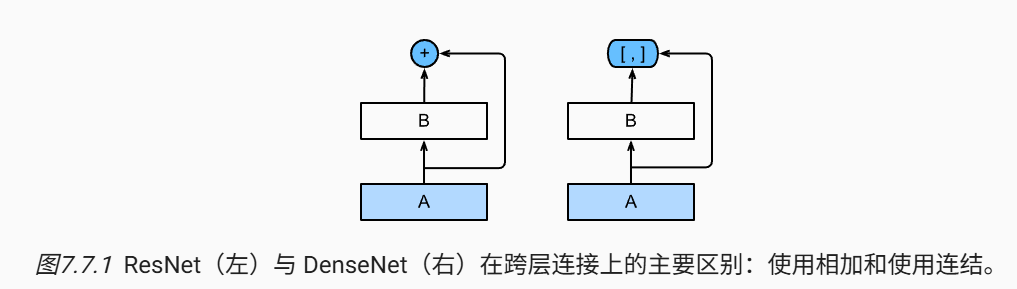
DenseNet输出是连接，而不是简单的相加。在应用越来越复杂的函数序列后，我们执行从$\mathbf{x}$到其展开式的映射：

$$\mathbf{x} \to \left[
\mathbf{x},
f_1(\mathbf{x}),
f_2([\mathbf{x}, f_1(\mathbf{x})]), f_3([\mathbf{x}, f_1(\mathbf{x}), f_2([\mathbf{x}, f_1(\mathbf{x})])]), \ldots\right].$$

最后，将这些展开式结合到多层感知机中，再次减少特征的数量。DenseNet这个名字由变量之间的“稠密连接”而得来，最后一层与之前的所有层紧密相连。

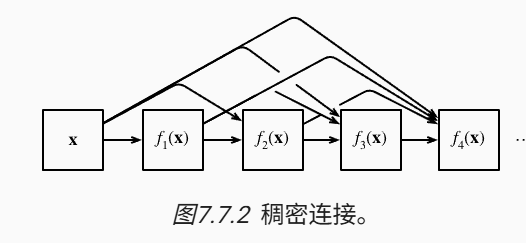

稠密网络主要由2部分构成：稠密块（dense block）和过渡层（transition layer）。 前者定义如何连接输入和输出，而后者则控制通道数量，使其不会太复杂。

##稠密块DenseBlock
稠密块（Dense Block）是 DenseNet 的核心模块：块内每一层都会接收前面所有层输出的拼接结果。
假设输入为 \(x_0\)，第 \(l\) 层的计算是：
$$
x_l = H_l([x_0, x_1, \dots, x_{l-1}])
$$其中：
- $[\,]$ 表示在通道维度拼接；
- $H_l$ 通常是一组 BN → ReLU → 卷积 操作；
- $x_l$ 是本层新产生的特征图。

一个四层的稠密块可以理解为：
```
输入 x0
  ├─→ 第1层 → x1
  ├─→ 第2层，输入 [x0, x1] → x2
  ├─→ 第3层，输入 [x0, x1, x2] → x3
  └─→ 第4层，输入 [x0, x1, x2, x3] → x4

输出：[x0, x1, x2, x3, x4]
```
稠密块会保留各层的原始特征，而不是将它们混合覆盖。

下面我们使用“批量规范化、激活和卷积”，尝试展示稠密块的结构。


In [13]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


def conv_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1))

class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(
                num_channels * i + input_channels, num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
            # 每经过一个网络块，就把该块的输出拼接回原输入，作为下一个块的输入
        return X

在下面的例子中，我们定义一个有2个输出通道数为10的DenseBlock。
使用通道数为3的输入时，我们会得到通道数为$3+2\times 10=23$的输出。
卷积块的通道数控制了输出通道数相对于输入通道数的增长，因此也被称为*增长率*（growth rate）。


In [14]:
blk = DenseBlock(2, 3, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

##过渡层Transition Layer
过渡层位于两个稠密块之间，作用是：控制特征图规模，避免通道数在不断拼接后增长过快。它通过$1\times 1$卷积层来减小通道数，并使用步幅为2的平均池化层减半高和宽，从而进一步降低模型复杂度。


In [15]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

对上一个例子中稠密块的输出使用通道数为10的过渡层。 此时输出的通道数减为10，高和宽均减半。

In [16]:
blk = transition_block(23, 10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

##DenseNet模型和训练


In [17]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

接下来，类似于ResNet使用的4个残差块，DenseNet使用的是4个稠密块。
与ResNet类似，我们可以设置每个稠密块使用多少个卷积层。
这里我们设成4，从而与ResNet-18保持一致。
稠密块里的卷积层通道数（即增长率）设为32，所以每个稠密块将增加128个通道。

在每个模块之间，ResNet通过步幅为2的残差块减小高和宽，DenseNet则使用过渡层来减半高和宽，并减半通道数。


In [18]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

与ResNet类似，最后接上全局汇聚层和全连接层来输出结果。

In [19]:
net = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

下面是训练过程和训练结果

Epoch [1/10] | Train Loss: 0.5355 | Train Acc: 0.8116 | Test Acc: 0.7363
Epoch [2/10] | Train Loss: 0.3062 | Train Acc: 0.8880 | Test Acc: 0.8044
Epoch [3/10] | Train Loss: 0.2543 | Train Acc: 0.9076 | Test Acc: 0.8675
Epoch [4/10] | Train Loss: 0.2279 | Train Acc: 0.9159 | Test Acc: 0.8907
Epoch [5/10] | Train Loss: 0.2058 | Train Acc: 0.9255 | Test Acc: 0.7517
Epoch [6/10] | Train Loss: 0.1880 | Train Acc: 0.9311 | Test Acc: 0.8900
Epoch [7/10] | Train Loss: 0.1755 | Train Acc: 0.9360 | Test Acc: 0.8485
Epoch [8/10] | Train Loss: 0.1617 | Train Acc: 0.9413 | Test Acc: 0.8980
Epoch [9/10] | Train Loss: 0.1506 | Train Acc: 0.9450 | Test Acc: 0.9046
Epoch [10/10] | Train Loss: 0.1398 | Train Acc: 0.9495 | Test Acc: 0.8816


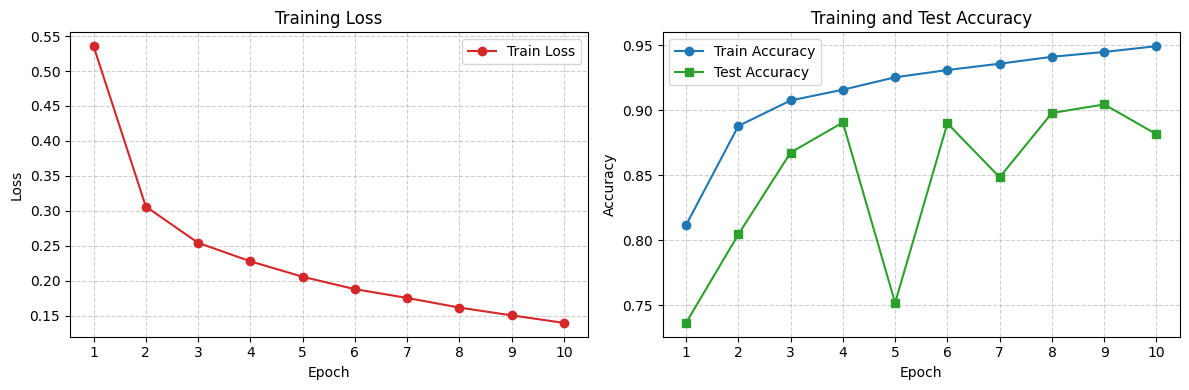

In [20]:

# ---------- 加载 Fashion-MNIST 数据集 ----------
batch_size = 256

transform = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_iter = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_iter = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)


# ---------- 初始化、准确率与测试函数 ----------
def init_weights(module):
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        nn.init.xavier_uniform_(module.weight)


def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).sum().item()


def evaluate_accuracy(net, data_iter, device):
    net.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)

            y_hat = net(X)
            correct += accuracy(y_hat, y)
            total += y.numel()

    return correct / total


# ---------- 训练 ----------
lr, num_epochs = 0.1, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net.apply(init_weights)
net.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

train_losses = []
train_accs = []
test_accs = []

for epoch in range(num_epochs):
    net.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for X, y in train_iter:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_hat = net(X)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * y.shape[0]
        train_correct += accuracy(y_hat, y)
        train_total += y.shape[0]

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total
    test_acc = evaluate_accuracy(net, test_iter, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )


# ---------- 绘制 Loss 和 Accuracy 曲线 ----------
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

# Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, "o-", color="tab:red", label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.xticks(list(epochs))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, "o-", color="tab:blue", label="Train Accuracy")
plt.plot(epochs, test_accs, "s-", color="tab:green", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.xticks(list(epochs))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

训练效果波动比较大，这可能是学习率 lr=0.1 固定不变且偏大导致的。

1. 为什么过渡层使用平均汇聚而不是最大汇聚？

DenseNet 的稠密块会将不同层产生的特征直接拼接并保留下来。过渡层的目标是对这些特征进行较平稳的压缩和下采样。
平均汇聚会综合一个局部区域内的所有响应，更适合保留整体特征分布；最大汇聚只保留最强响应，可能丢弃其他层复用的细节特征。DenseNet 原论文因此采用平均汇聚，使稠密连接得到的多层特征能更平滑地传递到下一稠密块。
不过这属于经典 DenseNet 的设计选择，并非最大汇聚一定不能用；实际任务中也可以比较两者效果。

2. 为什么 DenseNet 的模型参数通常比 ResNet 小？

关键是 特征复用。
ResNet 的每个残差块通常都要学习一组较完整的新特征，并通过相加与原特征融合。为了保证表达能力，很多层需要保持较大的通道数，因此卷积参数较多。
DenseNet 中，前面各层的输出会直接拼接给后续层使用。后面的层可以直接利用已有的边缘、纹理、形状等特征，不必反复学习相似内容。因此每一层只需产生少量新特征图，即较小的增长率 $k$。
卷积参数量大致与输入通道数、输出通道数和卷积核面积成正比：
$$
\text{参数量} \approx C_{\text{in}} \times C_{\text{out}} \times K^2
$$
DenseNet 虽然因拼接使 $C_{\text{in}}$ 逐层增加，但每层的 $C_{\text{out}}$ 通常只有增长率 $k$，例如 12、24 或 32；而 ResNet 中许多卷积层的输出通道数可能是 64、128、256、512。
因此，在相近精度下，DenseNet 往往能用更少的卷积参数实现有效特征提取。代价是它需要保存并拼接更多中间特征，显存访问和训练时间不一定更低。